<a href="https://colab.research.google.com/github/EnricoABM/umc-ia/blob/main/Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática – Engenharia de Atributos (Feature Engineering)

##  🎯 Objetivo

Aplicar conceitos de feature engineering e avaliar como novas variáveis podem melhorar o desempenho de um modelo de Random Forest na predição de sobrevivência de passageiros do Titanic.

## 🧩 Instruções
* Baixe o dataset do Kaggle – Titanic: Machine Learning from Disaster.
* Link: https://www.kaggle.com/competitions/titanic

Implemente um modelo básico de Random Forest com as variáveis originais:

Pclass, Sex, Age, Fare
Esse será o Modelo A (baseline).

Crie e teste duas novas features obrigatórias:

* FamilySize = SibSp + Parch + 1

* IsAlone = (FamilySize == 1).astype(int)

Compare o desempenho entre o Modelo A e o Modelo B (com as duas novas features) usando validação cruzada (cross_val_score).

Pense e implemente mais 3 novas features criadas por você ou seu grupo.
Cada feature deve ter uma justificativa lógica (social, biológica ou contextual).

Treine novamente o modelo incluindo essas 5 novas variáveis e analise:

* Acurácia média

* Importância das variáveis (feature_importances_ ou permutation_importance)

Discussão sobre quais features realmente ajudaram o modelo.

## 🧠 Perguntas para responder
* Qual foi a acurácia média antes e depois das novas features?

* Quais variáveis foram mais importantes segundo o modelo?

* Alguma feature criada teve efeito negativo no desempenho?

* Que paralelos podem ser feitos com sua área (ex.: variáveis derivadas em dados biológicos, clínicos ou experimentais)?

Data Dictionary

| Variable | Definition | Key |
|----------|------------|-----|
| survival | Survival |	0 = No, 1 = Yes |
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex |	Sex |
| Age |	Age in years |
| sibsp | # of siblings / spouses aboard the Titanic	 parch # of parents / children aboard the Titanic |
| ticket | Ticket number |
| fare | Passenger fare |
| cabin | Cabin number |
| embarked | Port of Embarkation |	C = Cherbourg, Q = Queenstown, S = Southampton |

# Bibliotecas e Variáveis

In [66]:
# Bibliotecas

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 42

CV = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Estética simples para plots (sem estilos específicos)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

def encoding_df(df, columns):
    ct = ColumnTransformer([
        ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columns)
    ], remainder='passthrough')

    arr = ct.fit_transform(df)

    # Pega os nomes das colunas codificadas
    ohe_cols = ct.named_transformers_['ohe'].get_feature_names_out(columns)

    # Pega os nomes das colunas que foram passadas sem transformação
    pass_cols = [col for col in df.columns if col not in columns]

    # Combina os nomes na ordem correta: primeiro as colunas codificadas, depois as passadas
    new_columns = list(ohe_cols) + pass_cols

    return pd.DataFrame(arr, columns=new_columns, index=df.index)

# Importação

In [67]:
# 1. Instalar a biblioteca do Kaggle
!pip install kaggle

# 2. Importar a biblioteca de arquivos e fazer o upload
from google.colab import files

print('Faça o upload do seu arquivo kaggle.json:')
files.upload()

# 3. Criar o diretório, mover o arquivo e definir permissões
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 4. Baixar os dados da competição Titanic
!kaggle competitions download -c titanic

# 5. Descompactar o dataset
!unzip -q titanic.zip

# 6. Listar os arquivos para confirmar
print('\nArquivos baixados e prontos para uso:')
!ls


Faça o upload do seu arquivo kaggle.json:


Saving kaggle.json to kaggle (1).json
titanic.zip: Skipping, found more recently modified local copy (use --force to force download)
replace gender_submission.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A

Arquivos baixados e prontos para uso:
 gender_submission.csv	 kaggle.json   test.csv      train.csv
'kaggle (1).json'	 sample_data   titanic.zip


# Carregando Dataset

In [68]:
# Carregando Dataset
df = pd.read_csv('train.csv')

In [69]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Tratamento Básico dos Dados

In [71]:
# Alterando a variável target

df['Survived'] = df['Survived'].map({0: 'Não', 1: 'Sim'})

In [72]:
# Idade = Média das idades

df['Age'] = df['Age'].fillna(df['Age'].mean())


# Encoding Simples

In [73]:
# Encoding Simples

df = encoding_df(df, ['Sex'])

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Sex_female   891 non-null    object
 1   Sex_male     891 non-null    object
 2   PassengerId  891 non-null    object
 3   Survived     891 non-null    object
 4   Pclass       891 non-null    object
 5   Name         891 non-null    object
 6   Age          891 non-null    object
 7   SibSp        891 non-null    object
 8   Parch        891 non-null    object
 9   Ticket       891 non-null    object
 10  Fare         891 non-null    object
 11  Cabin        204 non-null    object
 12  Embarked     889 non-null    object
dtypes: object(13)
memory usage: 90.6+ KB


# Modelo A

## Separação dos dados

In [75]:
df_a = df[['Pclass', 'Sex_male', 'Sex_female', 'Age', 'Fare', 'Survived']].copy()

X = df_a.drop('Survived', axis=1)
Y = df_a['Survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

X_train.shape, Y_train.shape

((712, 5), (712,))

## Treino do Modelo A

In [76]:
df_a.head()

,Pclass,Sex_male,Sex_female,Age,Fare,Survived
0,3,1.0,0.0,22.0,7.25,Não
1,1,0.0,1.0,38.0,71.2833,Sim
2,3,0.0,1.0,26.0,7.925,Sim
3,1,0.0,1.0,35.0,53.1,Sim
4,3,1.0,0.0,35.0,8.05,Não


In [77]:
rf_a = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_a.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [78]:
Y_pred = rf_a.predict(X_test)

In [79]:
# Métricas
acc_a = cross_val_score(rf_a, X_train, Y_train, cv=CV, scoring="accuracy", n_jobs=-1)

importances_base_a = pd.Series(rf_a.feature_importances_, index=X.columns).sort_values(ascending=False)

# Modelo B

In [80]:
df_b = df.copy()

df_b['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df_b['IsAlone'] = (df_b['FamilySize'] == 1).astype(int)

df_b.head()

,Sex_female,Sex_male,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,0.0,1.0,1,Não,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.25,NaN,S,2,0
1,1.0,0.0,2,Sim,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,1.0,0.0,3,Sim,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.925,NaN,S,1,1
3,1.0,0.0,4,Sim,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1,C123,S,2,0
4,0.0,1.0,5,Não,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.05,NaN,S,1,1


In [81]:
df_b = df_b[['Pclass', 'Sex_male', 'Sex_female', 'Age', 'Fare', 'Survived', 'FamilySize', 'IsAlone']].copy()

X = df_b.drop('Survived', axis=1)
Y = df_b['Survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

X_train.shape, Y_train.shape

((712, 7), (712,))

## Treino do Modelo

In [82]:
# Modelo B
rf_b = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_b.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [83]:
Y_pred = rf_b.predict(X_test)

In [84]:
acc_b = cross_val_score(rf_b, X_train, Y_train, cv=CV, scoring="accuracy", n_jobs=-1)

importances_base_b = pd.Series(rf_b.feature_importances_, index=X.columns).sort_values(ascending=False)

# Resultados Modelo A e B

In [85]:
print(f'Acurácia A: {acc_a.mean()} ± {acc_a.std()}')
print(f'Acurácia B: {acc_b.mean()} ± {acc_b.std()}')


Acurácia A: 0.8089234708953018 ± 0.02494413215990173
Acurácia B: 0.8032995173840245 ± 0.03777555278577329


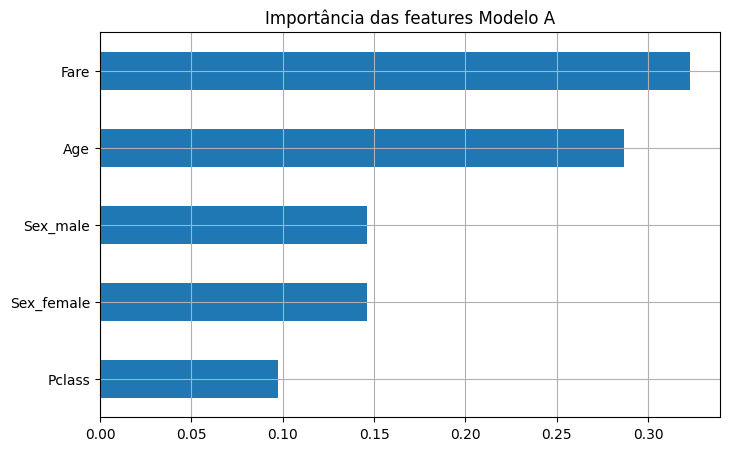

In [86]:
ax = importances_base_a.sort_values().plot.barh()
ax.set_title("Importância das features Modelo A")
plt.show()

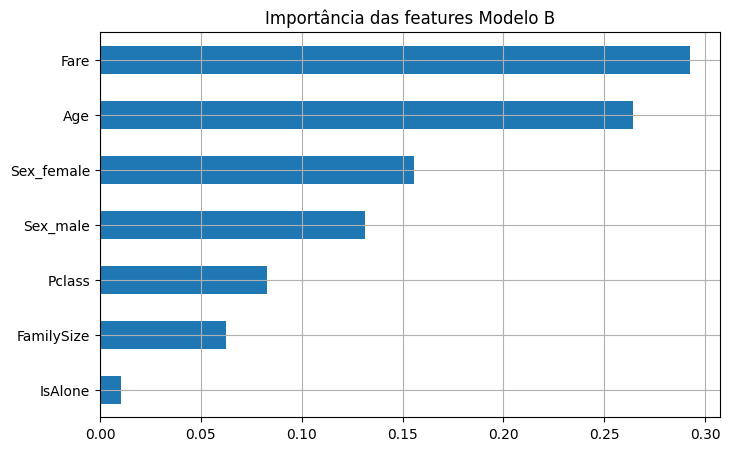

In [87]:
ax = importances_base_b.sort_values().plot.barh()
ax.set_title("Importância das features Modelo B")
plt.show()

# Novos atributos

In [88]:
df_c = df.copy()

df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Sex_female   891 non-null    object
 1   Sex_male     891 non-null    object
 2   PassengerId  891 non-null    object
 3   Survived     891 non-null    object
 4   Pclass       891 non-null    object
 5   Name         891 non-null    object
 6   Age          891 non-null    object
 7   SibSp        891 non-null    object
 8   Parch        891 non-null    object
 9   Ticket       891 non-null    object
 10  Fare         891 non-null    object
 11  Cabin        204 non-null    object
 12  Embarked     889 non-null    object
dtypes: object(13)
memory usage: 90.6+ KB


Criança - Jovem - Adulto - Idoso
* Jovens e Adultos possuem mais probabilidade de reagir a emergências do que Crianças e Idosos.
* Idosos possuem mobilidade reduzida e Crianças são dependentes de seus responsáveis

| Idade | Classificação |
|-------|---------------|
| `I <= 12` | Criança |
| `12 < I <= 18` | Jovem |
|  `18 > I <= 60` | Adulto |
| `I > 60` | Idoso |  

In [89]:
# Faixa Etária

def categorize_age(age):
    if (age <= 12):
        return 'Criança'
    elif (12 < age <= 18):
        return 'Jovem'
    elif (18 < age <= 60):
        return 'Adulto'
    else:
        return 'Idoso'

df_c['AgeGroup'] = df_c['Age'].apply(categorize_age)

df_c.head()

,Sex_female,Sex_male,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,AgeGroup
0,0.0,1.0,1,Não,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.25,NaN,S,Adulto
1,1.0,0.0,2,Sim,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,Adulto
2,1.0,0.0,3,Sim,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.925,NaN,S,Adulto
3,1.0,0.0,4,Sim,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1,C123,S,Adulto
4,0.0,1.0,5,Não,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.05,NaN,S,Adulto


Deck
* Tenta determinar a posição dentro do navio, o que pode demonstrar se os sobreviventes estavam em áreas semelhantes durante o acidente.

In [90]:
df_c['Cabin'] = df_c['Cabin'].fillna('Unknow')

df_c['Deck'] = df_c['Cabin'].str[0]

df_c['Deck'].value_counts()

,count
Deck,
U,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


Grupo de Pessoas que estão viajando juntas.
* Além de familias, podemos ter grupos de amigos e outros associados.
* Verificamos se esse grupo pode impactar na decisão do modelo.

In [91]:
ticket_counts = df_c['Ticket'].value_counts()
df_c['TicketCount'] = df_c['Ticket'].map(ticket_counts)


In [92]:
df_c['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df_c['IsAlone'] = (df_c['FamilySize'] == 1).astype(int)


In [93]:
df_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Sex_female   891 non-null    object
 1   Sex_male     891 non-null    object
 2   PassengerId  891 non-null    object
 3   Survived     891 non-null    object
 4   Pclass       891 non-null    object
 5   Name         891 non-null    object
 6   Age          891 non-null    object
 7   SibSp        891 non-null    object
 8   Parch        891 non-null    object
 9   Ticket       891 non-null    object
 10  Fare         891 non-null    object
 11  Cabin        891 non-null    object
 12  Embarked     889 non-null    object
 13  AgeGroup     891 non-null    object
 14  Deck         891 non-null    object
 15  TicketCount  891 non-null    int64 
 16  FamilySize   891 non-null    object
 17  IsAlone      891 non-null    int64 
dtypes: int64(2), object(16)
memory usage: 125.4+ KB


# Modelo C

In [94]:
df_c = df_c[['Pclass', 'Sex_male', 'Sex_female', 'Age', 'Fare', 'Survived', 'FamilySize', 'IsAlone', 'Deck', 'TicketCount', 'AgeGroup']].copy()

## Pre-Processamento

In [95]:
df_c = encoding_df(df_c, ['Deck', 'AgeGroup'])

## Separação dos Dados

In [96]:
X = df_c.drop('Survived', axis=1)
Y = df_c['Survived']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=RANDOM_STATE)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((712, 21), (179, 21), (712,), (179,))

## Treino do Modelo

In [97]:
# Modelo C
rf_c = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_c.fit(X_train, Y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

## Teste do Modelo

In [98]:
Y_pred = rf_c.predict(X_test)

## Métricas

In [99]:
acc_c = cross_val_score(rf_c, X_train, Y_train, cv=CV, scoring="accuracy", n_jobs=-1)

importances_base_c = pd.Series(rf_c.feature_importances_, index=X.columns).sort_values(ascending=False)

## Comparação de Métricas

In [100]:
print(f'Acurácia A: {acc_a.mean():.2f} ± {acc_a.std():.2f}')
print(f'Acurácia B: {acc_b.mean():.2f} ± {acc_b.std():.2f}')
print(f'Acurácia C: {acc_c.mean():.2f} ± {acc_c.std():.2f}')

Acurácia A: 0.81 ± 0.02
Acurácia B: 0.80 ± 0.04
Acurácia C: 0.80 ± 0.02


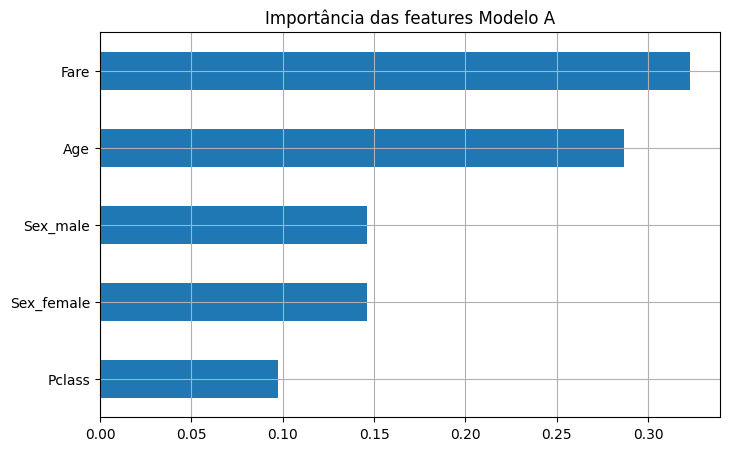

In [101]:
ax = importances_base_a.head(7).sort_values().plot.barh()
ax.set_title("Importância das features Modelo A")
plt.show()

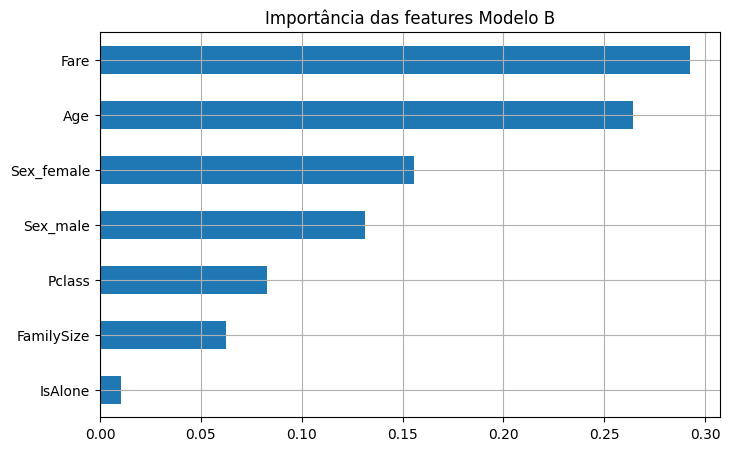

In [102]:
ax = importances_base_b.head(7).sort_values().plot.barh()
ax.set_title("Importância das features Modelo B")
plt.show()


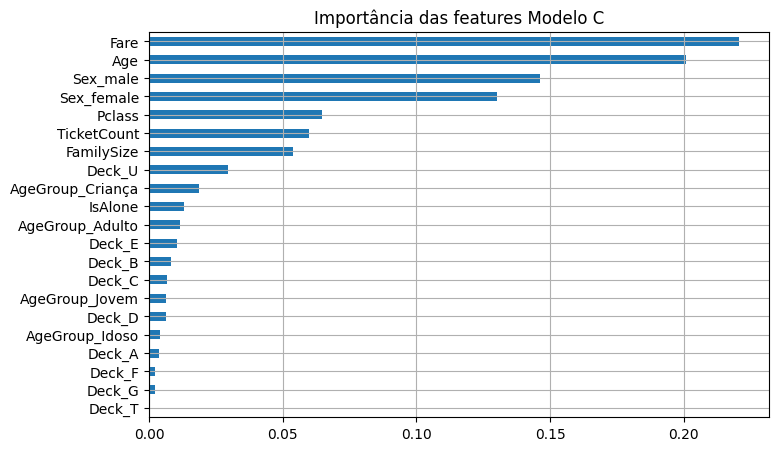

In [104]:
ax = importances_base_c.sort_values().plot.barh()
ax.set_title("Importância das features Modelo C")
plt.show()


# Questionário
* Qual foi a acurácia média antes e depois das novas features?

| Modelo | Acurácia |
|--------|----------|
| A | 81% |
| B | 80% |
| C | 80% |

* Quais variáveis foram mais importantes segundo o modelo?

> Fare

* Alguma feature criada teve efeito negativo no desempenho?

> As 2 features criadas trouxeram uma redução de 1% na precisão do modelo, 1 feature demonstrou se assemelhar ao tamanho da familia.


* Que paralelos podem ser feitos com sua área (ex: variáveis derivadas em dados biológicos, clínicos ou experimentais)?

> Deck -> A posição da cabine não demonstrou eficaz para verificar a taxa de sobrevivência. Talvez por a posição da sua cabine importar.

> Ticket Group -> O tamanho do grupo se assemelha ao tamanho da familia. Então o grupo de pessoas em conjunto auxilia na taxa de sobrevivência.

> Age Group -> Deve pouco impacto na decisão, porém demonstrou que Crianças possuem mais chance de sobrevivência, possivelmente por serem levadas e protegidas mais que os demais, e não possuem mobilidade reduzida igual a idosos.   